In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [48]:
df=pd.read_csv("/content/goog.csv")
df.head(5)

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400


In [49]:
df.isna().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0


In [50]:
df.describe()

,Open,High,Low,Close,Volume
count,61.000000,61.000000,61.000000,61.000000,6.100000e+01
mean,814.005573,817.755576,809.734066,814.561804,1.361269e+06
std,18.784303,18.556004,19.384799,19.265955,4.987376e+05
min,778.809998,782.780029,770.409973,771.820007,6.234000e+05
25%,799.679993,802.700012,793.270020,801.340027,1.057900e+06
50%,809.510010,815.250000,804.539978,809.559998,1.247700e+06
75%,828.659973,833.250000,825.059998,830.630005,1.494500e+06
max,851.609985,853.400024,847.109985,852.119995,3.228900e+06


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [33]:
def createDataset(dataset,timestamp):
  x=[];
  y=[];
  for i in range(len(dataset)-timestamp):
    x.append(dataset[i:i+timestamp])
    y.append(dataset[i+timestamp])
  return np.array(x),np.array(y)


In [52]:
data=df['Close'].values

In [53]:
data.shape

(61,)

In [54]:
data.dtype

dtype('float64')

In [55]:
data

array([794.200012, 796.419983, 794.559998, 791.26001 , 789.909973,
       791.549988, 785.049988, 782.789978, 771.820007, 786.140015,
       786.900024, 794.02002 , 806.150024, 806.650024, 804.789978,
       807.909973, 806.359985, 807.880005, 804.609985, 806.070007,
       802.174988, 805.02002 , 819.309998, 823.869995, 835.669983,
       832.150024, 823.309998, 802.320007, 796.789978, 795.695007,
       798.530029, 801.48999 , 801.340027, 806.969971, 808.380005,
       809.559998, 813.669983, 819.23999 , 820.450012, 818.97998 ,
       824.159973, 828.070007, 831.659973, 830.76001 , 831.330017,
       828.640015, 829.280029, 823.210022, 835.23999 , 830.630005,
       829.080017, 827.780029, 831.909973, 835.369995, 838.679993,
       843.25    , 845.539978, 845.619995, 847.200012, 848.780029,
       852.119995])

In [56]:
train_size=int(len(data)*0.8)
train_size

48

In [57]:
scaler=MinMaxScaler()
data=scaler.fit_transform(data.reshape(-1,1))

In [58]:
train_data=data[:train_size]
test_data=data[train_size:]

In [59]:
test_data

array([[0.7897882 ],
       [0.73237866],
       [0.7130762 ],
       [0.69688705],
       [0.74831849],
       [0.79140719],
       [0.8326276 ],
       [0.88953927],
       [0.91805706],
       [0.91905354],
       [0.93872997],
       [0.95840639],
       [1.        ]])

In [60]:
x_train,y_train=createDataset(train_data,4)
x_test,y_test=createDataset(test_data,4)

In [61]:
y_test

array([[0.74831849],
       [0.79140719],
       [0.8326276 ],
       [0.88953927],
       [0.91805706],
       [0.91905354],
       [0.93872997],
       [0.95840639],
       [1.        ]])

In [62]:
x_train.shape

(44, 4, 1)

In [63]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,SimpleRNN

In [90]:
model=Sequential()
model.add(SimpleRNN(50,return_sequences=True))
model.add(SimpleRNN(50))
model.add(Dense(1))

In [91]:
model.compile(optimizer='adam',loss='mse',metrics=['mae','mse','accuracy'])

In [92]:
model.fit(x_train,y_train,epochs=70)

Epoch 1/70
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.0227 - loss: 0.1254 - mae: 0.2962 - mse: 0.1254
Epoch 2/70
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.0227 - loss: 0.0938 - mae: 0.2591 - mse: 0.0938    
Epoch 3/70
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0227 - loss: 0.0606 - mae: 0.1898 - mse: 0.0606 
Epoch 4/70
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0227 - loss: 0.0273 - mae: 0.1382 - mse: 0.0273    
Epoch 5/70
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.0227 - loss: 0.0533 - mae: 0.2002 - mse: 0.0533
Epoch 6/70
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.0227 - loss: 0.0386 - mae: 0.1661 - mse: 0.0386
Epoch 7/70
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.0227 - loss: 0.0193 - mae: 0.1119 - mse: 0.0193 
Epoch 8/70
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.0227 - loss: 0.0281 - mae: 0.1294 - mse: 0.0281
Epoch 9/70
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.0227 - loss: 0.0292 - mae: 0.1353 - mse

In [73]:
x_test.shape

(9, 4, 1)

In [93]:
y_pred=model.predict(x_test)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step


array([[0.64434975],
       [0.68841064],
       [0.74209297],
       [0.75663877],
       [0.79372233],
       [0.8099027 ],
       [0.7905352 ],
       [0.79754055],
       [0.8188161 ]], dtype=float32)

In [94]:
model.evaluate(x_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 625ms/step - accuracy: 0.1111 - loss: 0.0173 - mae: 0.1282 - mse: 0.0173


[0.017257442697882652,
 0.12823671102523804,
 0.017257442697882652,
 0.1111111119389534]

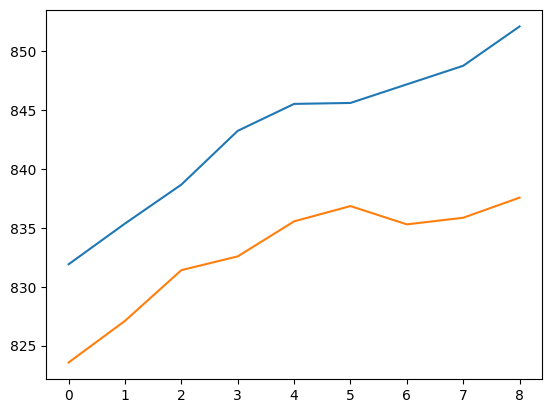

In [95]:
plt.plot(scaler.inverse_transform(y_test),label="Actual")
plt.plot(scaler.inverse_transform(y_pred),label="Predicted")